<a href="https://colab.research.google.com/github/radithyaairlangga/boilerplate-demographic-data-analyzer/blob/main/last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DATA GRAPH EXPLORER ===

Pilih sumber CSV:
1. Upload dari komputer
2. Masukkan URL CSV
3. Gunakan URL yang sudah ditentukan di kode
Pilihan (1/2/3): 3
Menggunakan URL: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv

=== DATAFRAME ===
     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4    

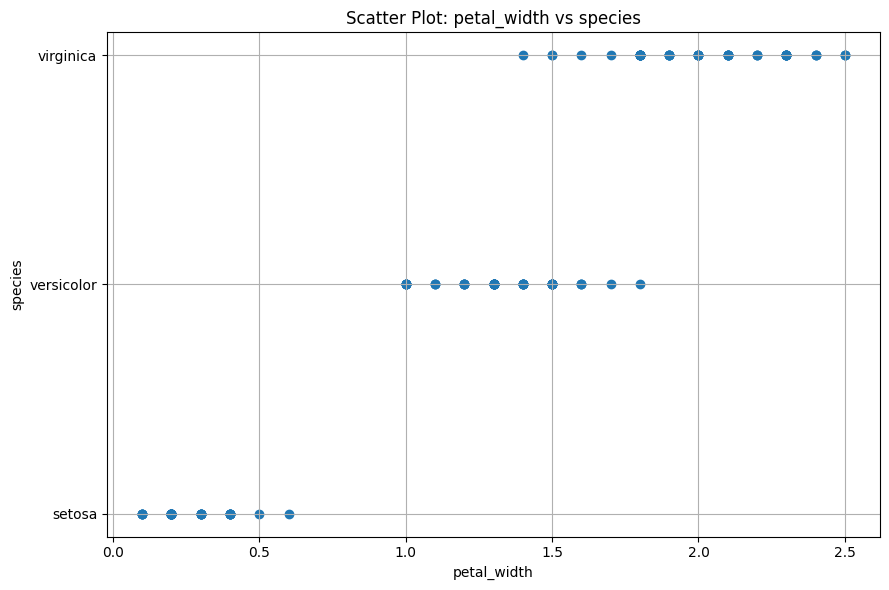


=== GRAPH INTERPRETATION ===
Interpretasi otomatis tidak tersedia karena salah satu kolom bukan data numerik.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import requests


# ============================================================
# 1. GET CSV FILE
# ============================================================

print("=== DATA GRAPH EXPLORER ===")
print()
print("Pilih sumber CSV:")
print("1. Upload dari komputer")
print("2. Masukkan URL CSV")
print("3. Gunakan URL yang sudah ditentukan di kode")

choice = input("Pilihan (1/2/3): ")


# URL CSV yang bisa ditentukan langsung di kode
CODE_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"


if choice == "1":
    # Untuk Google Colab / Jupyter
    try:
        from google.colab import files

        uploaded = files.upload()

        filename = list(uploaded.keys())[0]

        df = pd.read_csv(BytesIO(uploaded[filename]))

    except ImportError:
        # Fallback untuk Python biasa
        filename = input("Masukkan nama file CSV: ")
        df = pd.read_csv(filename)


elif choice == "2":

    url = input("Masukkan URL CSV: ")

    try:
        df = pd.read_csv(url)
    except Exception as e:
        print("Gagal membaca CSV dari URL.")
        print("Error:", e)
        exit()


elif choice == "3":

    print("Menggunakan URL:", CODE_URL)

    try:
        df = pd.read_csv(CODE_URL)
    except Exception as e:
        print("Gagal membaca CSV dari URL.")
        print("Error:", e)
        exit()


else:
    print("Pilihan tidak valid.")
    exit()


# ============================================================
# 2. DISPLAY DATAFRAME
# ============================================================

print("\n=== DATAFRAME ===")
print(df)


# ============================================================
# 3. PRINT HEADINGS AND FIRST TWO ROWS
# ============================================================

print("\n=== COLUMN HEADINGS ===")
print(df.columns.tolist())

print("\n=== FIRST TWO ROWS ===")
print(df.head(2))


# ============================================================
# 4. STORE COLUMN NAMES AS A LIST
# ============================================================

column_names = df.columns.tolist()

print("\n=== COLUMN NAMES AS LIST ===")
print(column_names)


# ============================================================
# 5. SHOW AVAILABLE COLUMNS
# ============================================================

print("\n=== AVAILABLE COLUMNS ===")

for i, column in enumerate(column_names):
    print(f"{i}: {column}")


# ============================================================
# 6. CHOOSE X AND Y COLUMNS
# ============================================================

x_index = int(input("\nPilih nomor kolom X: "))
y_index = int(input("Pilih nomor kolom Y: "))

x_column = column_names[x_index]
y_column = column_names[y_index]

print("\nX =", x_column)
print("Y =", y_column)


# ============================================================
# 7. CONVERT DATA TO NUMPY ARRAYS
# ============================================================

x = df[x_column].to_numpy()
y = df[y_column].to_numpy()

print("\n=== NUMPY ARRAYS ===")

print("X:")
print(x)

print("\nY:")
print(y)


# ============================================================
# 8. CHOOSE GRAPH TYPE
# ============================================================

print("\n=== GRAPH TYPE ===")
print("1. Scatter Plot")
print("2. Line Graph")

graph_type = input("Pilih grafik (1/2): ")


# ============================================================
# 9. CREATE GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

if graph_type == "1":

    plt.scatter(x, y)

    plt.xlabel(x_column)
    plt.ylabel(y_column)

    plt.title(
        f"Scatter Plot: {x_column} vs {y_column}"
    )

elif graph_type == "2":

    plt.plot(x, y, marker="o")

    plt.xlabel(x_column)
    plt.ylabel(y_column)

    plt.title(
        f"Line Graph: {x_column} vs {y_column}"
    )

else:

    print("Jenis grafik tidak valid.")
    exit()


plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 10. BASIC GRAPH INTERPRETATION
# ============================================================

print("\n=== GRAPH INTERPRETATION ===")

if pd.api.types.is_numeric_dtype(df[x_column]) and \
   pd.api.types.is_numeric_dtype(df[y_column]):

    correlation = df[x_column].corr(df[y_column])

    print(
        f"Korelasi antara {x_column} dan {y_column}: "
        f"{correlation:.3f}"
    )

    if correlation >= 0.7:
        print("Interpretasi: hubungan positif yang kuat.")

    elif correlation >= 0.3:
        print("Interpretasi: hubungan positif sedang.")

    elif correlation > -0.3:
        print("Interpretasi: hubungan linear relatif lemah.")

    elif correlation > -0.7:
        print("Interpretasi: hubungan negatif sedang.")

    else:
        print("Interpretasi: hubungan negatif yang kuat.")

else:

    print(
        "Interpretasi otomatis tidak tersedia karena "
        "salah satu kolom bukan data numerik."
    )